In [ ]:
from dotenv import load_dotenv
import neptune
load_dotenv('.tokens.env', override=True)
import plotly.io as pio
pio.renderers.default = "svg" # uncomment this if want interactive renderer

In [2]:
import neptune

project = neptune.init_project(project='pmtest/subexit')
project

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/pmtest/subexit/


In [3]:
params = project.fetch_runs_table(tag='mt-ood').to_pandas()

Fetching table...: 0 [00:00, ?/s]

In [4]:
# params:

# 3 algos

# num_boxes 4 --> 10


# y - 'solved/rate/full'
params['algo'] = params['sys/tags'].apply(lambda x: x.split('- arxiv')[0])
params['algo'].value_counts()

algo
KSubS - k4         56
BestFS             56
KSubS - k8         56
AdaSubS - k841     56
Name: count, dtype: int64

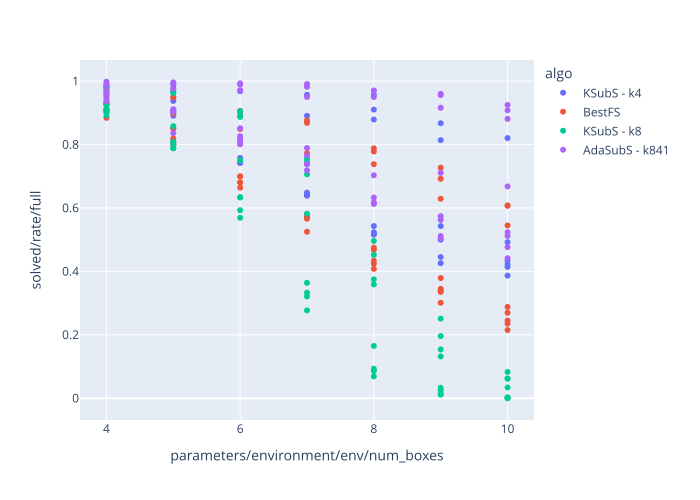

In [5]:
import plotly.express as px

px.scatter(params, x='parameters/environment/env/num_boxes', y='solved/rate/full', color='algo')

In [6]:
params['parameters/algorithm/data_loader/generator/path_to_folder_with_data'].unique()
params['num_boxes'] = params['parameters/environment/env/num_boxes']
params['generator steps'] = params['parameters/algorithm/data_loader/generator/path_to_folder_with_data'].apply(lambda x:int(x.split('_gs')[1].split('_')[0]))
params['curriculum'] = params['parameters/algorithm/data_loader/generator/path_to_folder_with_data'].apply(lambda x: int(x.split('_c')[1].split('_')[0]))
params['prob_change_direction'] = params['parameters/algorithm/data_loader/generator/path_to_folder_with_data'].apply(lambda x: float(x.split('_p')[1]))

In [7]:
params['generator steps'].value_counts()

generator steps
25     112
100    112
Name: count, dtype: int64

In [8]:
params['curriculum'].value_counts()

curriculum
300    224
Name: count, dtype: int64

In [9]:
params['prob_change_direction'].value_counts()

prob_change_direction
0.85    56
0.60    56
0.35    56
0.10    56
Name: count, dtype: int64

In [10]:
params.sort_values('num_boxes', ascending=True)

,sys/creation_time,sys/custom_run_id,sys/description,sys/failed,sys/group_tags,sys/hostname,sys/id,sys/modification_time,sys/monitoring_time,sys/name,...,monitoring/feab716e/memory,monitoring/feab716e/pid,monitoring/feab716e/stderr,monitoring/feab716e/stdout,monitoring/feab716e/tid,algo,num_boxes,generator steps,curriculum,prob_change_direction
93,2024-06-23 23:47:12.071,7ffbebcba3090dbc5d3d7b9aadb2dc5c -,Solve instances with AdaSubS,False,NaN,e2229,SUBEXIT-33288,2024-06-24 01:34:38.406,6446,solve_instances,...,NaN,NaN,NaN,NaN,NaN,KSubS - k8,4,100,300,0.35
41,2024-06-27 21:36:46.351,06f25bb740a34f77130900065ed902f4 -,Solve instances with AdaSubS,False,,e1204,SUBEXIT-33340,2024-06-27 21:53:22.956,997,solve_instances,...,NaN,NaN,NaN,NaN,NaN,KSubS - k4,4,100,300,0.10
162,2024-06-23 23:45:45.021,df4a804da0e7a94b4214436739458b2d -,,False,NaN,e2090,SUBEXIT-33219,2024-06-23 23:58:30.837,766,sokoban_bestfs,...,NaN,NaN,NaN,NaN,NaN,BestFS,4,25,300,0.35
74,2024-06-23 23:47:44.307,70a6745416029dbb846e8e522f49c866 -,,False,NaN,e2094,SUBEXIT-33307,2024-06-23 23:58:28.902,645,sokoban_bestfs,...,NaN,NaN,NaN,NaN,NaN,BestFS,4,25,300,0.60
73,2024-06-23 23:47:44.352,1c76976274b2cf014a191ced06989940 -,Solve instances with AdaSubS,False,NaN,e2232,SUBEXIT-33308,2024-06-24 01:16:03.074,5299,solve_instances,...,NaN,NaN,NaN,NaN,NaN,KSubS - k8,4,25,300,0.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2024-06-23 23:47:11.904,4fdbc13432a0a1938fe26b4d3e6d0892 -,Solve instances with AdaSubS,False,NaN,e2361,SUBEXIT-33283,2024-06-24 00:19:22.919,1931,solve_instances,...,NaN,NaN,NaN,NaN,NaN,KSubS - k8,10,100,300,0.85
97,2024-06-23 23:47:11.942,9b6dba2ea36bbce9904555947b3a5974 -,Solve instances with AdaSubS,False,NaN,e2363,SUBEXIT-33284,2024-06-24 00:10:45.404,1414,solve_instances,...,NaN,NaN,NaN,NaN,NaN,KSubS - k8,10,25,300,0.35
160,2024-06-23 23:46:12.546,0870b536f70d5df58c8984269f7c870b -,,False,NaN,e2226,SUBEXIT-33221,2024-06-24 00:41:51.438,3339,sokoban_bestfs,...,NaN,NaN,NaN,NaN,NaN,BestFS,10,25,300,0.10
143,2024-06-23 23:46:15.391,8349ff22d5b7d16e1269e6b82631d540 -,,False,NaN,e2228,SUBEXIT-33238,2024-06-24 00:42:41.605,3386,sokoban_bestfs,...,NaN,NaN,NaN,NaN,NaN,BestFS,10,25,300,0.60


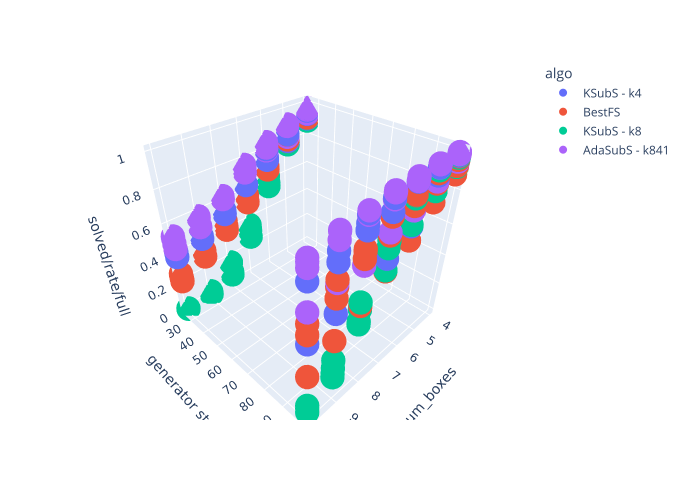

In [11]:
px.scatter_3d(params, x='num_boxes', y='generator steps', z='solved/rate/full', color='algo')

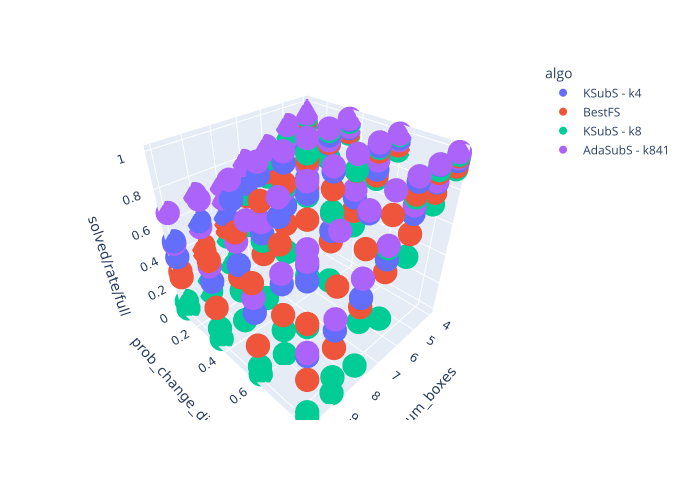

In [12]:
px.scatter_3d(params, x='num_boxes', y='prob_change_direction', z='solved/rate/full', color='algo')

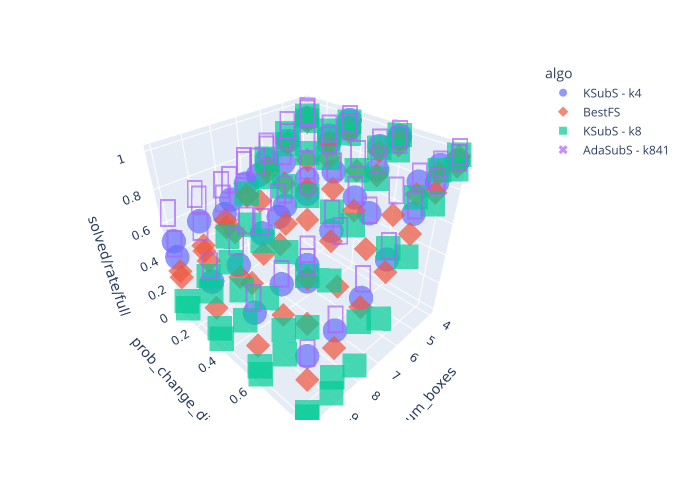

In [13]:
px.scatter_3d(params, x='num_boxes', y='prob_change_direction', z='solved/rate/full', color='algo', opacity=0.7, symbol='algo')

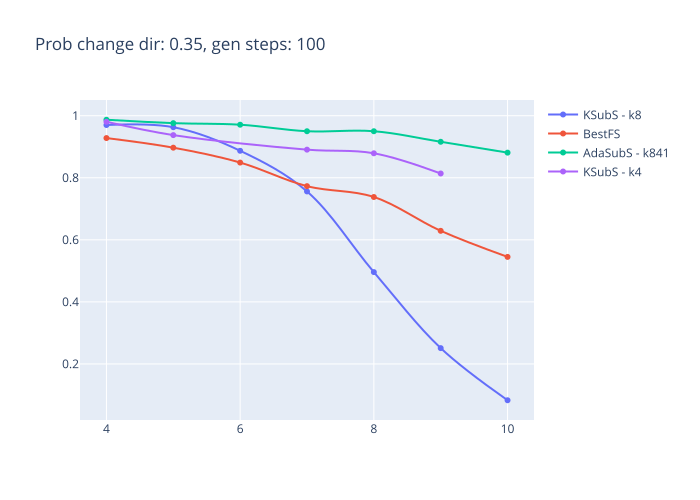

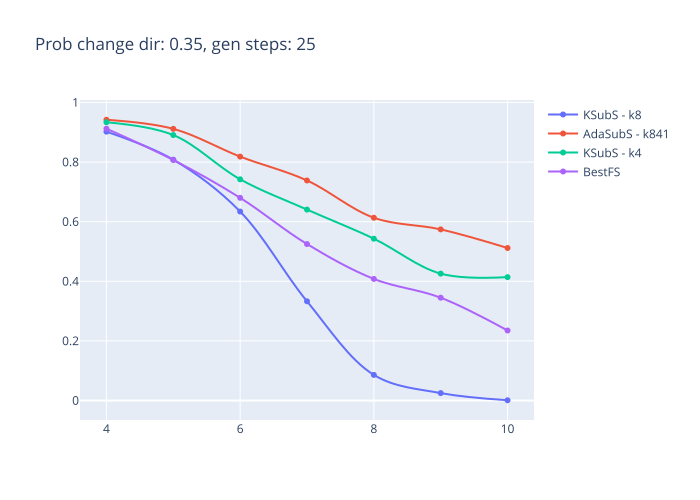

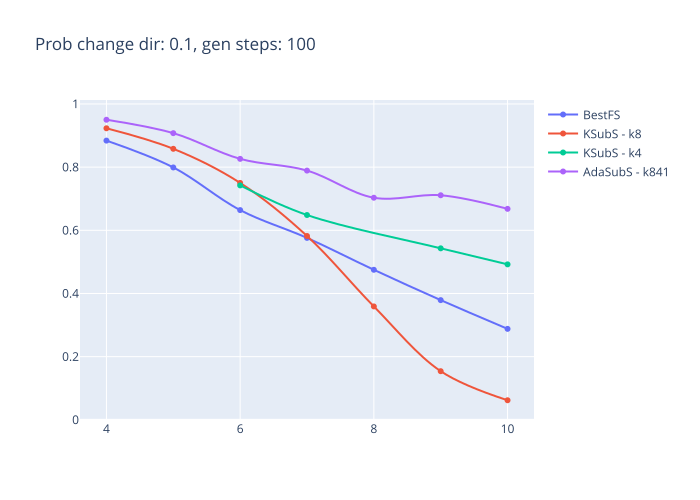

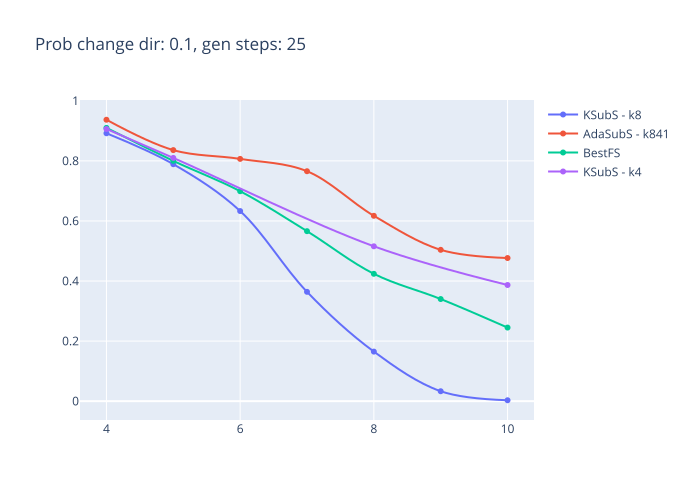

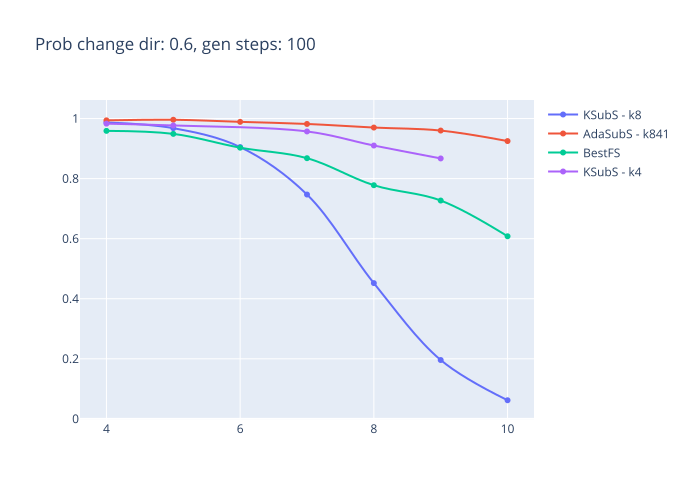

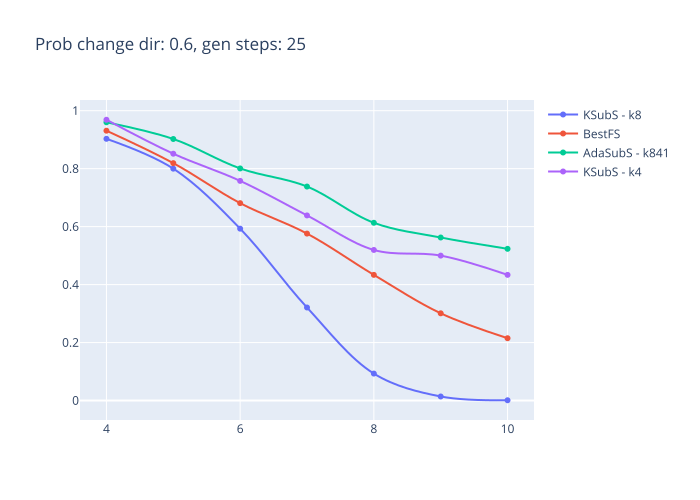

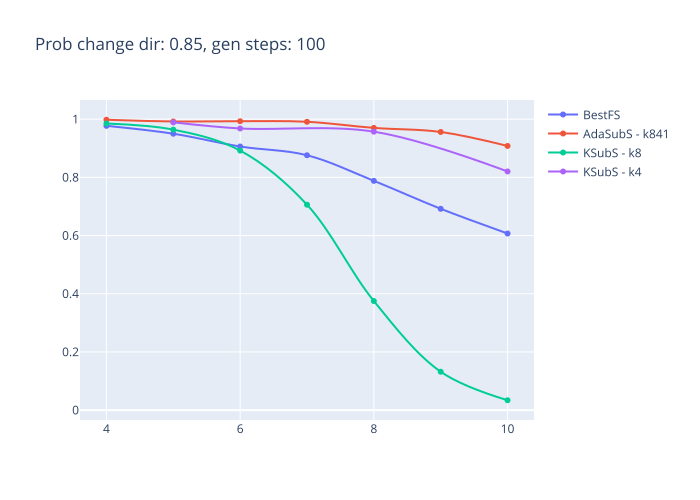

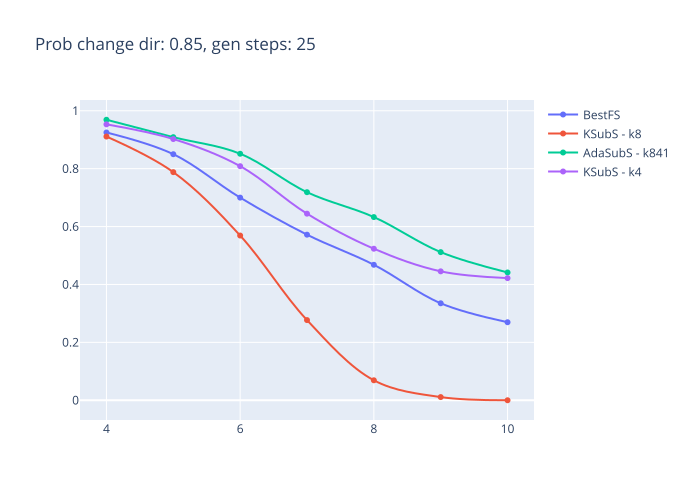

In [15]:
import plotly.graph_objects as go
import itertools
prob_change_dir = params['prob_change_direction'].unique().tolist()
gen_steps = params['generator steps'].unique().tolist()

params.sort_values('num_boxes', ascending=True, inplace=True)

for prob_change_dir, gen_steps in itertools.product(prob_change_dir, gen_steps):
    subparams = params[(params['prob_change_direction'] == prob_change_dir) & (params['generator steps'] == gen_steps)]
    fig = go.Figure()
    for algo in subparams['algo'].unique():
        subsubparams = subparams[subparams['algo'] == algo]
        fig.add_trace(go.Scatter(x=subsubparams['num_boxes'], y=subsubparams['solved/rate/full'], mode='lines+markers', name=algo, line_shape='spline', connectgaps=True))
    fig.update_layout(title=f'Prob change dir: {prob_change_dir}, gen steps: {gen_steps}')
    fig.show()